# Lesson 03 — Building makemore Part 2: MLP

- **GitHub issue:** [#3](https://github.com/majorgilles/karpathy_ml_course/issues/3)
- **Video:** https://youtu.be/TCH_1BHY58I
- **Lesson guide:** [../README.md](../README.md)
- **Transcript:** [../transcript.md](../transcript.md)

Use this notebook for exploratory follow-along work. Move reusable code to `../src/`, lightweight checks to `../tests/`, and representative outputs to `../artifacts/`.

## 1. Load names and prepare the MLP workspace

This lesson moves beyond a bigram model: the MLP will use a fixed number of previous characters, called a **context window**, to predict the next character. First load the names as Python strings and establish the small set of libraries used for tensors, one-hot encoding, and later visualizations.

Each element of `words` is one name. The early cells inspect a few names and the dataset size before converting characters into numeric model inputs.


In [1]:
import torch  # Tensor operations and model parameters.
import torch.nn.functional as F  # One-hot encoding and other neural-network helpers.
import matplotlib.pyplot as plt  # Visualizations used later in the lesson.
from sympy.codegen.ast import float32  # Current exploration import; not used by these cells yet.
%matplotlib inline

In [2]:
# Load every name; each line in names.txt becomes one training sequence.
from pathlib import Path

candidate_paths = [
    Path("data/raw/names.txt"),  # Kernel launched from the repository root.
    Path("../../../data/raw/names.txt"),  # Kernel launched from this notebook folder.
]
names_path = next(path for path in candidate_paths if path.exists())
words = names_path.read_text(encoding="utf-8").splitlines()

words[:8]  # Inspect a small sample before building numeric examples.

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# Confirm how many complete name sequences are available.
len(words)

32033

## 2. Map characters to model-friendly IDs

Neural networks work with numbers, not Python characters. `stoi` means string-to-index and maps each character to one stable integer; `itos` reverses that lookup for readable examples and generated output.

The boundary token `.` receives index `0`. It represents both left padding before a name and the end of a name, so the context window can start before any real letters have appeared.


In [4]:
# Collect the 26 lowercase letters once and sort them for reproducible IDs.
chars = sorted(list(set(''.join(words))))
# Reserve 0 for the boundary token, so letters begin at index 1.
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
# Invert the mapping: model indices back to printable characters.
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 3. Turn names into fixed-context training examples

`block_size = 3` means every input row contains exactly three previous character IDs. `X` stores those three-character contexts and `Y` stores the one next-character target that followed each context.

For `emma`, the first example is `... → e`, then `..e → m`, and so on until `mma → .`. The initial three zeros are left padding with the boundary token. The dataset cell now iterates over all `words`, producing `N = len(X)` examples (`228,146` in the current run), so it avoids printing every transition.


In [5]:
# Build one (context, next-character) example for every transition in every loaded name.
BLOCK_SIZE = 3  # Number of preceding characters the model receives as input.
X, Y = [], []  # X holds context rows; Y holds one next-character target per row.

for w in words:  # Iterate over the full training dataset.
    context = [0] * BLOCK_SIZE  # Start with three boundary-token IDs: "...".

    for ch in w + ".":  # Include the final boundary token as a target.
        ix = stoi[ch]  # Integer ID of the character this context should predict.
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]  # Drop the oldest ID and append this target ID.

# Convert Python lists to integer tensors for embedding lookup in the MLP.
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
# Verify: one three-ID context per example and one integer next-character target.
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

### Split complete names before training

The model must learn from one group of names and be checked on different names. A fixed Python seed shuffles the complete names reproducibly, then the split uses 80% for training, 10% for development (also called validation), and 10% for final testing. Splitting names before generating character transitions prevents parts of one name from appearing in more than one split.

`build_dataset` turns each name group into context-target rows. In this run, `Xtr` and `Ytr` contain 182,625 training rows, `Xdev` and `Ydev` contain 22,655 development rows, and `Xte` and `Yte` contain 22,866 test rows. The percentages apply to names, so transition-row totals are not exactly 80/10/10 because names have different lengths. Parameter updates must use only `Xtr` and `Ytr`; development data helps choose settings later, and test data remains untouched until final evaluation.


In [7]:
# Turn one supplied name split into aligned context rows X and next-character targets Y.
def build_dataset(words: list) -> tuple[torch.Tensor, torch.Tensor]:
    X, Y = [], []
    for w in words:  # Keep every transition from this split together.
        context = [0] * BLOCK_SIZE  # Start with three boundary-token IDs: "...".

        for ch in w + ".":  # Include the final boundary token as a target.
            ix = stoi[ch]  # Integer ID of the character this context should predict.
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # Drop the oldest ID and append this target ID.

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)  # Inspect this split's context and target tensors.
    return X, Y

import random
random.seed(42)  # Reproduce the same name-level split on each rerun.
random.shuffle(words)  # Shuffle complete names before slicing; do not split individual transitions.
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# Build training, development, and test tensors from disjoint name groups.
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.int64 torch.Size([182625]) torch.int64
torch.Size([22655, 3]) torch.int64 torch.Size([22655]) torch.int64
torch.Size([22866, 3]) torch.int64 torch.Size([22866]) torch.int64


## 4. Look up embeddings for individual tokens, lists, and whole contexts

`C` is an embedding table with one row per vocabulary token. Each row now contains `EMBEDDING_SIZE = 10` learnable features. Integer indexing retrieves rows from that table: one ID gives one vector, a list of IDs gives several vectors, and a tensor of context IDs gives an embedding vector for every token in every context.

The active training lookup is `C[Xtr]`: `Xtr` contains `Ntr = len(Xtr)` training examples with 3 token IDs each, so the lookup replaces every ID with its 10-feature embedding. The result has shape `(Ntr, 3, 10)`: training examples, context positions, embedding features. In the current split, `Ntr = 182,625`; keep `Xdev` and `Xte` out of parameter updates.


In [8]:
# Create a 27-row embedding table; each token initially receives EMBEDDING_SIZE = 10 random features.
EMBEDDING_SIZE = 10
VOCAB_SIZE = 27
C = torch.randn((VOCAB_SIZE, EMBEDDING_SIZE))

In [9]:
# Direct lookup: one token ID selects one 10-feature embedding row.
C[5]

tensor([-0.0614, -0.9763,  0.0038,  1.7345, -0.5052, -1.8489,  0.8353, -0.7888,
         0.5242, -1.5311])

In [10]:
# A list of IDs selects several rows, preserving the list order: output shape (3, 10).
C[[5, 6, 7]]

tensor([[-0.0614, -0.9763,  0.0038,  1.7345, -0.5052, -1.8489,  0.8353, -0.7888,
          0.5242, -1.5311],
        [-2.1870,  0.6816,  1.8151, -0.4176,  1.0061, -0.1844,  0.7121, -0.0391,
          0.2487, -0.9116],
        [-0.2003, -1.7012, -0.1532, -1.1128, -1.3114, -0.0905, -0.0104, -0.3236,
         -0.8424,  0.4383]])

In [11]:
# Training lookup: replace every ID in Xtr with its C row, giving shape (Ntr, 3, 10).
emb = C[Xtr]
emb

tensor([[[-0.2111,  0.4880, -0.6981,  ...,  0.0348,  0.6046, -0.9592],
         [-0.2111,  0.4880, -0.6981,  ...,  0.0348,  0.6046, -0.9592],
         [-0.2111,  0.4880, -0.6981,  ...,  0.0348,  0.6046, -0.9592]],

        [[-0.2111,  0.4880, -0.6981,  ...,  0.0348,  0.6046, -0.9592],
         [-0.2111,  0.4880, -0.6981,  ...,  0.0348,  0.6046, -0.9592],
         [ 1.5411,  0.8773,  0.4452,  ...,  0.4473,  1.7282, -0.7852]],

        [[-0.2111,  0.4880, -0.6981,  ...,  0.0348,  0.6046, -0.9592],
         [ 1.5411,  0.8773,  0.4452,  ...,  0.4473,  1.7282, -0.7852],
         [-0.1759, -0.3888,  0.3136,  ...,  0.3223,  0.1841, -1.1314]],

        ...,

        [[ 0.3969, -0.1843, -0.7981,  ..., -0.4220, -0.4491,  0.1379],
         [ 0.5271, -0.5309,  0.9980,  ...,  0.8390, -1.0852, -1.3719],
         [-1.0621, -0.4365, -0.6781,  ..., -2.2009,  0.2740, -0.6261]],

        [[ 0.5271, -0.5309,  0.9980,  ...,  0.8390, -1.0852, -1.3719],
         [-1.0621, -0.4365, -0.6781,  ..., -2.2009,  0.

In [12]:
# Inspect the three axes: training examples, context positions, and embedding features.
emb.shape

torch.Size([182625, 3, 10])

## 5. Flatten each context into one MLP input row

`emb` has shape `(Ntr, 3, 10)`, where `Ntr = len(Xtr)` is the number of training examples, 3 is the number of context positions, and 10 is the number of embedding features per position. The first linear layer expects one feature vector per example, so reshape combines the last two dimensions into 30 features while preserving the batch dimension.

`emb.reshape(-1, EMBEDDING_SIZE * BLOCK_SIZE)` therefore produces shape `(Ntr, 30)`. The `-1` tells PyTorch to infer the number of examples. The `unbind` plus `cat` expression is an equivalent demonstration: split the three context positions into three `(Ntr, 10)` tensors, then concatenate them into `(Ntr, 30)`.

The comparison with `==` is elementwise, so it displays an `(Ntr, 30)` grid of `True` values. `torch.equal` would instead return one Boolean answer for the entire tensors.


In [13]:
# First linear layer: 30 flattened context features feed FIRST_HIDDEN_UNITS = 200 hidden neurons.
FIRST_HIDDEN_UNITS = 200
w1 = torch.randn((BLOCK_SIZE * EMBEDDING_SIZE, FIRST_HIDDEN_UNITS))
b1 = torch.randn(FIRST_HIDDEN_UNITS)  # One bias value per hidden neuron.

In [14]:
# Keep each example row and flatten its 3 × 10 context embedding into 30 MLP features.
reshaped = emb.reshape(-1, EMBEDDING_SIZE * BLOCK_SIZE)
# Elementwise check: every entry should be True because split-then-concatenate gives the same layout.
reshaped == torch.cat(torch.unbind(emb, dim=1), dim=1)

tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]])

## 6. Produce hidden activations with a linear layer and `tanh`

Matrix multiplication combines each 30-feature training-context row with `w1`: `(Ntr, 30) @ (30, 200) → (Ntr, 200)`, where `Ntr = len(Xtr)`. Adding `b1`, which has shape `(200,)`, broadcasts one bias per hidden neuron across all `Ntr` training examples.

$$
h = \tanh(\operatorname{flattened\_context} W_1 + b_1)
$$

Here, `h` is the `(Ntr, 200)` hidden-activation tensor, `W_1` is `w1`, and `b_1` is `b1`. `tanh` applies to every raw pre-activation score and maps it into the range from `-1` to `1`. This nonlinearity matters because stacked linear layers alone could be reduced to one linear transformation; `tanh` lets the MLP represent more complex relationships between context characters and the next target.


In [15]:
# Inspect the input, weight, and matrix-product shapes of the first linear layer.
print(reshaped.shape)
print(w1.shape)
print((reshaped @ w1).shape)
# Compute 200 linear pre-activation scores per example, then apply tanh element by element.
h = torch.tanh(reshaped @ w1 + b1)
# Confirm: one 200-feature hidden activation vector for each of the Ntr = len(Xtr) training examples.
h.shape

torch.Size([182625, 30])
torch.Size([30, 200])
torch.Size([182625, 200])


torch.Size([182625, 200])

## 7. Map hidden activations to one score per vocabulary candidate

Each of the `Ntr = len(Xtr)` training hidden vectors has 200 features. The output layer maps those features to 27 raw scores, one for every vocabulary candidate: the 26 letters plus the boundary token `.`.

$$
\operatorname{logits} = h W_2 + b_2
$$

`W_2` is `w2` with shape `(200, 27)`, `b_2` is `b2` with shape `(27,)`, and `h` has shape `(Ntr, 200)`. The resulting `logits` tensor has shape `(Ntr, 27)`: one row per training example and one column per candidate target character. Logits are raw preference scores, not probabilities; the next cells convert each row into a probability distribution.


In [16]:
# Output-layer weights map 200 hidden features to one raw score for each vocabulary candidate.
w2 = torch.randn((FIRST_HIDDEN_UNITS, VOCAB_SIZE))
b2 = torch.randn(VOCAB_SIZE)  # One bias value per output vocabulary candidate.

In [17]:
# Compute one raw candidate score per vocabulary token for each training example: (Ntr, 200) @ (200, 27) → (Ntr, 27).
logits = h @ w2 + b2
logits.shape

torch.Size([182625, 27])

## 8. Convert logits into probability distributions with manual softmax

`logits` contains 27 raw candidate scores per training example. Exponentiation makes every score positive; these intermediate values are named `counts` by convention here, but they are not observed character counts. Dividing each row by its own total gives 27 probabilities that add to one.

$$
p_{i,j} = \frac{\exp(\ell_{i,j})}{\sum_{k=0}^{26} \exp(\ell_{i,k})}
$$

Here, `i` identifies one of the `Ntr = len(Xtr)` training examples, `j` identifies one candidate vocabulary token, `k` ranges over all 27 candidates, and `ℓ` is a logit. The expected training target for example `i` is `Ytr[i]`; when the loss is introduced, `probs[i, Ytr[i]]` is the one probability that directly contributes to that example's negative log-likelihood.


In [18]:
# Exponentiate every raw score to create positive, unnormalized softmax values.
counts = logits.exp()

In [19]:
# Normalize each training example's 27 candidate values by its row total; keepdim preserves shape (Ntr, 1).
probs = counts / counts.sum(1, keepdim=True)
# Verify the output shape and that two example distributions each use the full probability budget of 1.
print(probs.shape)
print(probs[0].sum())
print(probs[1].sum())

torch.Size([182625, 27])
tensor(1.0000)
tensor(1.)


## 9. Select the probability assigned to each expected target

`probs` contains 27 candidate probabilities for each of the `Ntr = len(Xtr)` training examples, while `Ytr` contains one expected target ID per training example. Advanced indexing pairs training row `i` with column `Ytr[i]`, selecting exactly the probability the model assigned to the observed next character.

For training example 0, the selected value is `probs[0, Ytr[0]]`. `torch.arange(len(Xtr))` supplies the row IDs `0` through `Ntr - 1`, so `probs_for_labels` has shape `(Ntr,)`: one expected-target probability per training example. This scores only the training split; development and test data remain untouched.


In [20]:
# Pair each training row i with its expected target ID Ytr[i] to select one training-target probability.
probs_for_labels = probs[torch.arange(len(Xtr)), Ytr]
probs_for_labels.shape

torch.Size([182625])

## 10. Average the negative log-likelihood into one training loss

The loss should be small when the model gives a high probability to each expected target and large when it gives a low probability. Taking the logarithm makes probability values easier to combine, and the leading minus sign reverses the direction so better predictions have lower loss.

$$
\mathcal{L}_{\mathrm{train}} = -\frac{1}{N_{\mathrm{tr}}} \sum_{i=1}^{N_{\mathrm{tr}}} \log p_{i, Y^{\mathrm{tr}}_i}
$$

Here, `Ntr = len(Xtr)` is the number of training examples (`182,625` in the current split), `Ytr[i]` is the expected next-character ID for training row `i`, and `probs[i, Ytr[i]]` is that row's selected probability. The `.mean()` computes the average loss across all `Ntr` training examples, not a total. This is training-split loss, not development, test, or held-out evaluation loss. Next, backpropagation calculates how each parameter can change to lower this average loss.


In [21]:
# Take negative logs of the training-target probabilities, then average across all Ntr = len(Xtr) training examples.
loss = -probs_for_labels.log().mean()
loss

tensor(24.0187)

# Summary — split data and mini-batch training

The full names dataset is shuffled and split by complete name into training, development, and test groups. The training tensors `Xtr` and `Ytr` contain 182,625 context-target rows in this run; only they supply mini-batches for parameter updates. `Xdev`/`Ydev` will later help choose model settings, while `Xte`/`Yte` stay untouched until final evaluation.

The parameters begin random, then the training loop enables gradient tracking, calculates training loss, and updates them. Each iteration uses a fresh random mini-batch from `Xtr` and `Ytr`, making updates much faster while still learning from the training split over time.


In [22]:
# Confirm the training split has one three-token context and one target ID per training example.
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

## 11. Initialize one reproducible set of MLP parameters

A parameter is a number the model will later adjust to lower loss. The local random-number generator `g` starts from a fixed seed, so rerunning this cell with the same tensor shapes and order recreates the same random initial values. This makes experiments and explanations repeatable.

The model has five parameter tensors: embedding table `C`, first-layer weights `W1` and biases `b1`, then output-layer weights `W2` and biases `b2`. `parameters` groups them for counting now and for gradient-based updates later. `requires_grad=True` tells PyTorch to record how the loss depends on each tensor, so `loss.backward()` can later populate its gradient. With the current 10-feature embeddings and 200 hidden units, these tensors contain 11,897 scalar parameters in total.


In [23]:
# Use a local fixed seed so this parameter initialization is reproducible.
g = torch.Generator().manual_seed(2147483647)
# Each parameter tracks gradients so backpropagation can measure its effect on loss.
C = torch.randn(VOCAB_SIZE, EMBEDDING_SIZE, requires_grad=True, generator=g)
W1 = torch.randn((BLOCK_SIZE * EMBEDDING_SIZE, FIRST_HIDDEN_UNITS), requires_grad=True, generator=g)
b1 = torch.randn(FIRST_HIDDEN_UNITS, requires_grad=True, generator=g)
W2 = torch.randn((FIRST_HIDDEN_UNITS, VOCAB_SIZE), requires_grad=True, generator=g)
b2 = torch.randn(VOCAB_SIZE, requires_grad=True, generator=g)
# Keep the five trainable tensors together for gradient clearing and updates.
parameters = [C, W1, b1, W2, b2]

In [24]:
# Count scalar values across all five parameter tensors; this configuration contains 11,897 numbers.
sum(p.nelement() for p in parameters)

11897

## 12. Train only on random mini-batches from `Xtr` and `Ytr`

The tuned training configuration uses a three-character context (`BLOCK_SIZE = 3`), 10 embedding features per character (`EMBEDDING_SIZE = 10`), 200 hidden units (`FIRST_HIDDEN_UNITS = 200`), mini-batches of `B = MINIBATCH_SIZE = 32`, 60,000 updates, and fixed learning rate `lr = 0.1`. The training split has `Ntr = len(Xtr)` examples, but one update uses only `B` randomly selected training rows. `torch.randint(0, Xtr.shape[0], (B,))` creates `ix`, a length-`B` tensor of row IDs into the training split. It samples with replacement, so a training row can appear more than once in a batch and not every training row appears in a particular iteration.

The sampled tensors are `Xtr[ix]` and `Ytr[ix]`, so their rows remain paired: each training context still has its own expected next-character target. The mini-batch forward shape path is `(B, 3)` context IDs → `(B, 3, 10)` embeddings → `(B, 30)` flattened features → `(B, 200)` hidden activations → `(B, 27)` logits. `view(-1, EMBEDDING_SIZE * BLOCK_SIZE)` infers `B` from the selected rows. `Xdev`, `Ydev`, `Xte`, and `Yte` must not appear in this loop.

`F.cross_entropy(logits, Ytr[ix])` combines softmax with average NLL for this mini-batch's `B` training targets. Its printed value is a noisy training-loss estimate for sampled training rows, not development, test, or full-dataset loss. Before backpropagation, setting each `p.grad` to `None` clears gradients accumulated from an earlier iteration. `loss.backward()` calculates gradients, and the instructional `.data` update subtracts `lr × gradient` from every parameter. The active loop runs `NUMBER_ITERATIONS = 60,000` updates with fixed `lr = 0.1`. It records the update number and each sampled mini-batch loss for the training-curve plot. The `lre`/`lrs` cells still describe a currently inactive learning-rate-sweep experiment, so their values do not control the active update.


In [25]:
# Use 60,000 mini-batch parameter updates for the active fixed-learning-rate run.
NUMBER_ITERATIONS = 60_000
# Inactive experiment: exponents -3 through 0 create log-spaced candidate rates from 0.001 to 1.
lre = torch.linspace(-3, 0, NUMBER_ITERATIONS)
lrs = 10**lre

In [26]:
# B = 32 is the number of training examples used for one fast, noisy training-gradient estimate.
MINIBATCH_SIZE = 32
# Inspect only the tensors that supply parameter updates.
print(Xtr.shape)
print(Ytr.shape)

# Track update number and sampled training loss for a learning-curve plot; lri stores inactive sweep exponents.
lri = []
lossi = []
stepi = []
for i in range(NUMBER_ITERATIONS):
    # Sample B row IDs uniformly with replacement from the training split only.
    ix = torch.randint(0, Xtr.shape[0], (MINIBATCH_SIZE,))

    # Xtr[ix] and Ytr[ix] use the same training-row IDs, preserving context-target pairs.
    emb = C[Xtr[ix]]  # (B, 3, 10): look up embeddings for selected training contexts.
    h = torch.tanh(emb.view(-1, EMBEDDING_SIZE * BLOCK_SIZE) @ W1 + b1)  # (B, 200) hidden activations.
    logits = h @ W2 + b2  # (B, 27) raw scores for every vocabulary candidate.
    loss = F.cross_entropy(logits, Ytr[ix])  # Average NLL for this batch's B training targets.

    # Backward pass: clear old accumulated gradients, then calculate new training-loss gradients.
    for p in parameters:
        p.grad = None
    loss.backward()

    # Active update: move parameters opposite the training gradient with fixed learning rate 0.1.
    # To run the documented sweep instead, replace the next line with: lr = lrs[i].
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # Record the update index and this sampled mini-batch loss; this is not a dev-loss curve.
    lri.append(lre[i].item())
    stepi.append(i)
    lossi.append(loss.item())

print(loss.item())  # Final sampled training-mini-batch loss, not dev, test, or full-split loss.

torch.Size([182625, 3])
torch.Size([182625])
2.370469808578491


In [27]:
# Future learning-rate-sweep plot: activate lr = lrs[i] before interpreting lri versus lossi.
# plt.plot(lre, lossi)

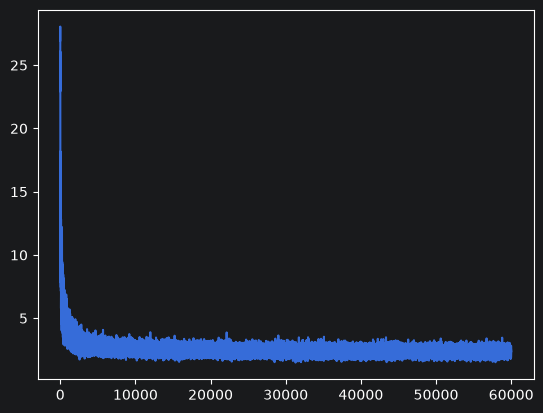

In [28]:
# Plot sampled training mini-batch loss by update number; expect noise because every batch differs.
plt.plot(stepi, lossi)

### Evaluate the tuned model on the development split

The next cell runs the current model across all `Ndev = len(Xdev) = 22,655` development examples, rather than a 32-row training mini-batch. Its shape path is `(Ndev, 3)` → `(Ndev, 3, 10)` → `(Ndev, 30)` → `(Ndev, 200)` → `(Ndev, 27)`. It computes development loss but performs no `backward()` call or parameter update. Compare this result with training behavior when choosing settings such as embedding size, hidden-layer width, mini-batch size, number of updates, and learning rate.

For efficiency, a later cleanup should wrap evaluation in `torch.no_grad()` because the current cell does not need gradients. Keep `Xte` and `Yte` untouched until the final model and settings are fixed; then evaluate once to estimate performance on unseen names.


In [29]:
# Evaluate every development context; no mini-batch sampling and no parameter update occur here.
emb = C[Xdev]  # (Ndev, 3, 10) development embeddings.
h = torch.tanh(emb.view(-1, EMBEDDING_SIZE * BLOCK_SIZE) @ W1 + b1)  # (Ndev, 200) activations.
logits = h @ W2 + b2  # (Ndev, 27) raw vocabulary scores.
loss = F.cross_entropy(logits, Ydev)  # Average development NLL across every dev target.
loss

tensor(2.3449, grad_fn=<NllLossBackward0>)